# Cross-Platform Popularity — Graph Construction & Evaluation

This notebook is the SAME for all 6 platforms (Facebook, TikTok, Twitter,
Reddit, YouTube, Instagram). Only `PLATFORM` changes. Keeping the code
identical across platforms is itself part of the audited protocol
(revision plan, Stage 2): every platform must go through exactly the same
pipeline so cross-platform comparisons are valid.

Implements revision-plan Stages 2–5:
  * Stage 2 — audited protocol: graph statistics + automated leakage check
  * Stage 3 — PR-AUC + paired per-seed deltas vs. no_graph baseline, with
              positive / trade-off / negligible / negative classification
  * Stage 4 — grouped SHAP (metadata / centrality / node2vec)
  * Stage 5 — targeted ablation + error-transition analysis (FP->TN, TP->FN,
              FN->TP, TN->FP)

No variant is treated as "the proposed method" — all variants, including
data_driven_homophily+node2vec64, are reported side by side (Stage 1 reframe).

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

import pandas as pd
import numpy as np

from graph_lib import (
    UNWEIGHTED_TABLE,
    compute_relation_weights,
    build_homophily_edges, build_similarity_knn_edges,
    compute_centrality_features, compute_node2vec_embeddings,
    compute_graph_statistics,
    evaluate_predictions, shap_summary, grouped_shap_summary,
    assign_feature_group, ablate_feature_group,
    error_transition_analysis, paired_delta_analysis,
    visualize_subgraph_sample,
    train_eval_variant,
    tuned_threshold_baseline,
    permutation_corrected_mi,
)

# ---- Only this block changes between platforms --------------------------
PLATFORM = "Tiktok"
SEEDS = [42, 123, 2024, 7, 99]
# ---------------------------------------------------------------------------

ML_DIR = Path("../../data_preprocess/processed_data/ml_data")
GRAPH_DIR = Path("../../data_preprocess/processed_data/graph_data")
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
NUMERIC_SIM_COLS = ["followers", "account_age_days", "content_length", "num_hashtags"]
BASELINE_VARIANT = "no_graph"
GRAPH_VARIANT_FOR_SHAP_ABLATION = "data_driven_homophily+node2vec64"

attrs_df = pd.read_csv(GRAPH_DIR / f"{PLATFORM.lower()}_graph.csv")

## Stage 1 — Build all graph variants per seed

Leakage control: `build_homophily_edges` / `build_similarity_knn_edges` only
keep an edge if at least one endpoint is a train node, so no test-test edge
can be created at construction time. `compute_graph_statistics` below
re-verifies this per seed/variant as an auditable check
(`n_test_test_edges` must be 0) rather than relying on that invariant silently.

In [2]:
graph_cache = {}
graph_stats_records = []

for seed in SEEDS:
    print(f"Building graphs for seed {seed}...")

    train_meta = pd.read_csv(ML_DIR / f"{PLATFORM.lower()}_train_seed{seed}.csv")
    test_meta = pd.read_csv(ML_DIR / f"{PLATFORM.lower()}_test_seed{seed}.csv")
    train_ids = set(train_meta["post_id"])
    test_ids = set(test_meta["post_id"])
    all_ids = list(train_ids | test_ids)

    nodes_df = attrs_df[attrs_df["post_id"].isin(all_ids)].copy()
    train_attrs = attrs_df[attrs_df["post_id"].isin(train_ids)].copy()

    weight_table, mi_scores = compute_relation_weights(train_attrs, label_col="popularity", seed=seed)
    print(f"  [seed {seed}] MI scores (mutual_info_classif, discrete features): "
          f"{dict((k, round(v, 4)) for k, v in mi_scores.items())}")
    print(f"  [seed {seed}] data-driven weights: {dict((k, round(v, 3)) for k, v in weight_table.items())}")

    edges_uw = build_homophily_edges(nodes_df, train_ids, UNWEIGHTED_TABLE)
    feat_uw, G_uw = compute_centrality_features(edges_uw, all_ids, betweenness_k=300, seed=seed)

    edges_knn = build_similarity_knn_edges(nodes_df, train_ids, NUMERIC_SIM_COLS, k=5)
    feat_knn, G_knn = compute_centrality_features(edges_knn, all_ids, betweenness_k=300, seed=seed)

    edges_dd = build_homophily_edges(nodes_df, train_ids, weight_table)
    feat_dd, G_dd = compute_centrality_features(edges_dd, all_ids, betweenness_k=300, seed=seed)

    emb_df = compute_node2vec_embeddings(G_dd, dimensions=64, walk_length=20, num_walks=20, workers=4, seed=seed)

    for variant_name, G in [("unweighted_homophily", G_uw),
                             ("similarity_knn", G_knn),
                             ("data_driven_homophily", G_dd)]:
        stats = compute_graph_statistics(G, train_ids, test_ids)
        stats.update({"platform": PLATFORM, "seed": seed, "variant": variant_name})
        graph_stats_records.append(stats)
        if stats["n_test_test_edges"] != 0:
            print(f"  !! LEAKAGE WARNING: {variant_name} seed {seed} has "
                  f"{stats['n_test_test_edges']} test-test edges")

    graph_cache[seed] = {
        "train_meta": train_meta,
        "test_meta": test_meta,
        "weight_table": weight_table,
        "mi_scores": mi_scores,
        "feature_sets": {
            "no_graph": None,
            "unweighted_homophily": feat_uw,
            "similarity_knn": feat_knn,
            "data_driven_homophily": feat_dd,
        },
        "emb_df": emb_df,
        "graph_object": G_dd,
    }
    print(f"  done. edges -> unweighted: {len(edges_uw)} | knn: {len(edges_knn)} | data-driven: {len(edges_dd)}")

pd.DataFrame(graph_stats_records).to_csv(RESULTS_DIR / f"{PLATFORM.lower()}_graph_statistics.csv", index=False)

weight_records = []
for seed, c in graph_cache.items():
    row = {"platform": PLATFORM, "seed": seed}
    row.update(c["weight_table"])
    weight_records.append(row)
pd.DataFrame(weight_records).to_csv(RESULTS_DIR / f"{PLATFORM.lower()}_relation_weights.csv", index=False)
print("\nAll graphs cached.")

Building graphs for seed 42...


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\cluster\_supervised.py:49: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_label = type_of_target(labels_true)


  [seed 42] MI scores (mutual_info_classif, discrete features): {'same_author': np.float64(0.4971), 'same_location': np.float64(0.0003), 'same_topic': np.float64(0.0009), 'same_language': np.float64(0.0004), 'same_media_type': np.float64(0.0002), 'same_toxicity_bin': np.float64(0.0009)}
  [seed 42] data-driven weights: {'same_author': np.float64(2.0), 'same_location': np.float64(0.5), 'same_topic': np.float64(0.502), 'same_language': np.float64(0.501), 'same_media_type': np.float64(0.5), 'same_toxicity_bin': np.float64(0.502)}
  done. edges -> unweighted: 57182 | knn: 43782 | data-driven: 57182
Building graphs for seed 123...


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\cluster\_supervised.py:49: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_label = type_of_target(labels_true)


  [seed 123] MI scores (mutual_info_classif, discrete features): {'same_author': np.float64(0.4965), 'same_location': np.float64(0.0001), 'same_topic': np.float64(0.0008), 'same_language': np.float64(0.0005), 'same_media_type': np.float64(0.0001), 'same_toxicity_bin': np.float64(0.001)}
  [seed 123] data-driven weights: {'same_author': np.float64(2.0), 'same_location': np.float64(0.5), 'same_topic': np.float64(0.502), 'same_language': np.float64(0.501), 'same_media_type': np.float64(0.5), 'same_toxicity_bin': np.float64(0.503)}
  done. edges -> unweighted: 57173 | knn: 43702 | data-driven: 57173
Building graphs for seed 2024...


...

  [seed 2024] MI scores (mutual_info_classif, discrete features): {'same_author': np.float64(0.4969), 'same_location': np.float64(0.0003), 'same_topic': np.float64(0.0007), 'same_language': np.float64(0.0008), 'same_media_type': np.float64(0.0), 'same_toxicity_bin': np.float64(0.0014)}
  [seed 2024] data-driven weights: {'same_author': np.float64(2.0), 'same_location': np.float64(0.501), 'same_topic': np.float64(0.502), 'same_language': np.float64(0.502), 'same_media_type': np.float64(0.5), 'same_toxicity_bin': np.float64(0.504)}
  done. edges -> unweighted: 57111 | knn: 43668 | data-driven: 57111
Building graphs for seed 7...


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\cluster\_supervised.py:49: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_label = type_of_target(labels_true)


  [seed 7] MI scores (mutual_info_classif, discrete features): {'same_author': np.float64(0.4972), 'same_location': np.float64(0.0001), 'same_topic': np.float64(0.0009), 'same_language': np.float64(0.0006), 'same_media_type': np.float64(0.0001), 'same_toxicity_bin': np.float64(0.0008)}
  [seed 7] data-driven weights: {'same_author': np.float64(2.0), 'same_location': np.float64(0.5), 'same_topic': np.float64(0.502), 'same_language': np.float64(0.502), 'same_media_type': np.float64(0.5), 'same_toxicity_bin': np.float64(0.502)}
  done. edges -> unweighted: 57165 | knn: 44037 | data-driven: 57165
Building graphs for seed 99...


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\cluster\_supervised.py:49: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_label = type_of_target(labels_true)


  [seed 99] MI scores (mutual_info_classif, discrete features): {'same_author': np.float64(0.4972), 'same_location': np.float64(0.0004), 'same_topic': np.float64(0.0009), 'same_language': np.float64(0.0009), 'same_media_type': np.float64(0.0), 'same_toxicity_bin': np.float64(0.0009)}
  [seed 99] data-driven weights: {'same_author': np.float64(2.0), 'same_location': np.float64(0.501), 'same_topic': np.float64(0.503), 'same_language': np.float64(0.502), 'same_media_type': np.float64(0.5), 'same_toxicity_bin': np.float64(0.503)}
  done. edges -> unweighted: 57140 | knn: 43842 | data-driven: 57140

All graphs cached.


## Optional visual sanity checks (unchanged)

  OK: Do not maintain test-test in this subsample.


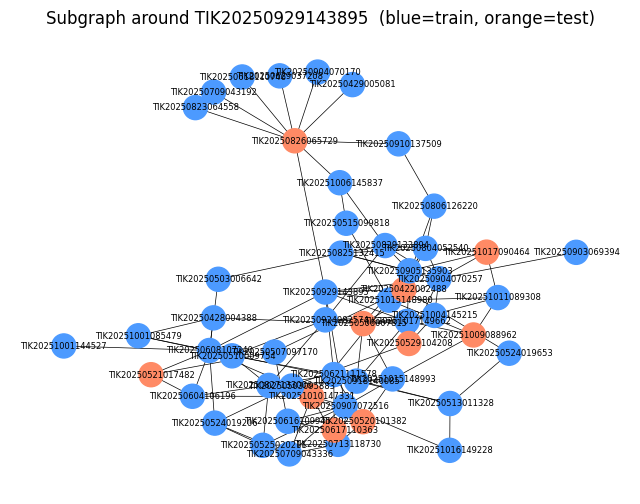

  OK: Do not maintain test-test in this subsample.


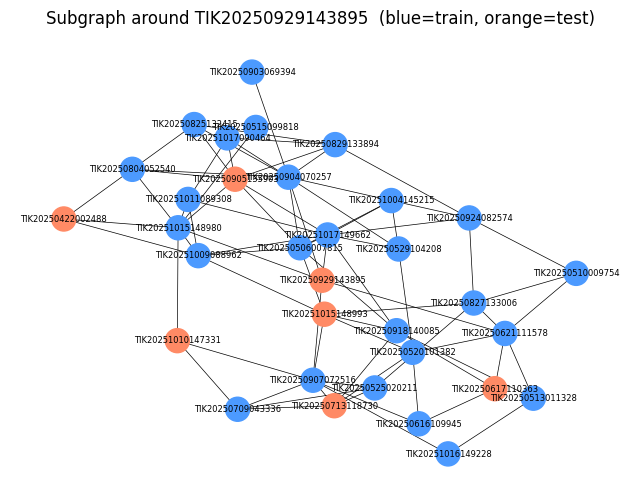

  OK: Do not maintain test-test in this subsample.


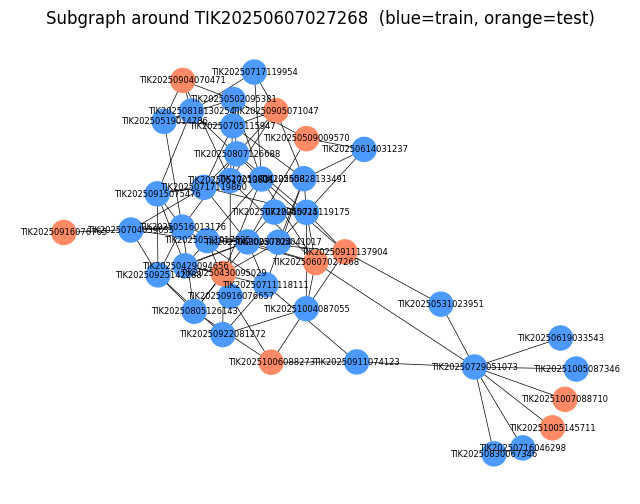

  OK: Do not maintain test-test in this subsample.


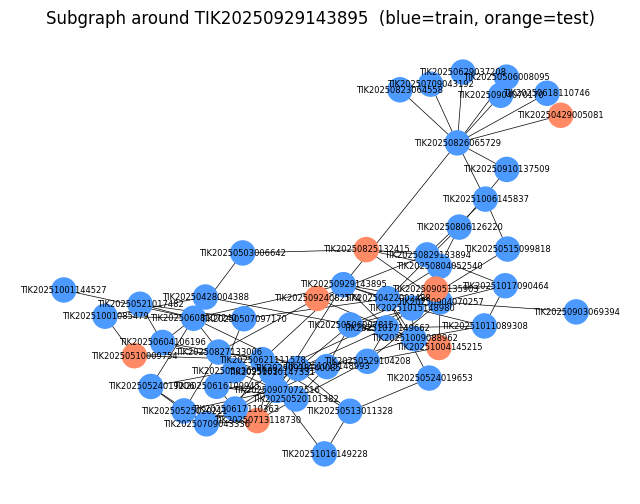

  OK: Do not maintain test-test in this subsample.


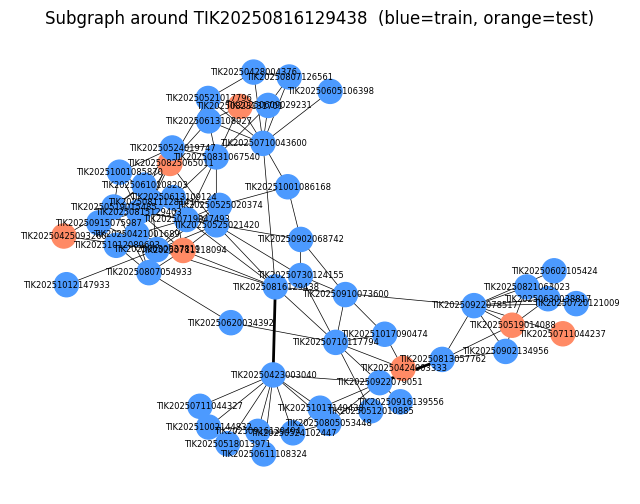

In [3]:
for seed in SEEDS:
    G_check = graph_cache[seed]["graph_object"]
    train_ids_seed = set(graph_cache[seed]["train_meta"]["post_id"])
    visualize_subgraph_sample(G_check, train_ids_seed,
                               save_path=RESULTS_DIR / f"subgraph_check_seed{seed}.png")

## Stage 3 — Train every variant per seed, keep predictions for later analysis

All variants (including no_graph) are reported symmetrically — none is
singled out as "the proposed method" per Stage 1 of the revision plan.

In [4]:
all_results = []
predictions_cache = {}  # (seed, variant) -> {"y_test":..., "y_pred":..., "model":..., "X_test":...}

for seed in SEEDS:
    print("\n" + "=" * 70 + f"\nSEED {seed}\n" + "=" * 70)
    cache = graph_cache[seed]
    train_meta, test_meta = cache["train_meta"], cache["test_meta"]
    emb_df = cache["emb_df"]

    for variant_name, feat_df in cache["feature_sets"].items():
        tr, te = train_meta.copy(), test_meta.copy()
        if feat_df is not None:
            tr = tr.merge(feat_df, on="post_id", how="left")
            te = te.merge(feat_df, on="post_id", how="left")

        metrics, model, X_test, y_test, y_pred = train_eval_variant(tr, te, seed=seed)
        metrics.update({"platform": PLATFORM, "variant": variant_name, "seed": seed})
        all_results.append(metrics)
        predictions_cache[(seed, variant_name)] = {
            "y_test": y_test, "y_pred": y_pred, "model": model, "X_test": X_test
        }
        print(f"  [{variant_name:35s}] F1={metrics['f1']:.4f}  PR-AUC={metrics['pr_auc']:.4f}  "
              f"ROC-AUC={metrics['roc_auc']:.4f}")

    # combined graph-derived variant: data-driven homophily centrality + node2vec
    feat_dd = cache["feature_sets"]["data_driven_homophily"]
    tr = train_meta.merge(feat_dd, on="post_id", how="left").merge(emb_df, on="post_id", how="left")
    te = test_meta.merge(feat_dd, on="post_id", how="left").merge(emb_df, on="post_id", how="left")

    metrics, model, X_test, y_test, y_pred = train_eval_variant(tr, te, seed=seed)
    metrics.update({"platform": PLATFORM, "variant": GRAPH_VARIANT_FOR_SHAP_ABLATION, "seed": seed})
    all_results.append(metrics)
    predictions_cache[(seed, GRAPH_VARIANT_FOR_SHAP_ABLATION)] = {
        "y_test": y_test, "y_pred": y_pred, "model": model, "X_test": X_test
    }
    print(f"  [{GRAPH_VARIANT_FOR_SHAP_ABLATION:35s}] F1={metrics['f1']:.4f}  "
          f"PR-AUC={metrics['pr_auc']:.4f}  ROC-AUC={metrics['roc_auc']:.4f}")

    # Stage 4 — grouped SHAP for the combined variant, this seed
    sample = X_test.sample(min(500, len(X_test)), random_state=seed)
    group_summary, feature_contrib, _ = grouped_shap_summary(model, sample, seed=seed)
    group_summary.insert(0, "seed", seed)
    group_summary.insert(0, "platform", PLATFORM)
    group_summary.to_csv(RESULTS_DIR / f"shap_groups_{PLATFORM.lower()}_seed{seed}.csv", index=False)
    shap_summary(model, sample, save_path=RESULTS_DIR / f"shap_{PLATFORM.lower()}_seed{seed}.png")

results_df = pd.DataFrame(all_results)
results_df.to_csv(RESULTS_DIR / f"{PLATFORM.lower()}_graph_comparison_raw.csv", index=False)


SEED 42
  [no_graph                           ] F1=0.6065  PR-AUC=0.6746  ROC-AUC=0.8705
  [unweighted_homophily               ] F1=0.5993  PR-AUC=0.6680  ROC-AUC=0.8699
  [similarity_knn                     ] F1=0.6000  PR-AUC=0.6702  ROC-AUC=0.8712
  [data_driven_homophily              ] F1=0.5998  PR-AUC=0.6696  ROC-AUC=0.8704
  [data_driven_homophily+node2vec64   ] F1=0.5974  PR-AUC=0.6686  ROC-AUC=0.8681


C:\Users\Admin\Documents\SNA_Nguyen Thai Thien Y_Huynh Tran Ai Nu\SNA_Nguyen Thai Thien Y_Huynh Tran Ai Nu\Network_graph\graph_lib.py:225: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, max_display=max_display, show=False)



SEED 123
  [no_graph                           ] F1=0.6284  PR-AUC=0.7004  ROC-AUC=0.8917
  [unweighted_homophily               ] F1=0.6141  PR-AUC=0.6866  ROC-AUC=0.8833
  [similarity_knn                     ] F1=0.6291  PR-AUC=0.7039  ROC-AUC=0.8909
  [data_driven_homophily              ] F1=0.6154  PR-AUC=0.6848  ROC-AUC=0.8813
  [data_driven_homophily+node2vec64   ] F1=0.6209  PR-AUC=0.6908  ROC-AUC=0.8854


C:\Users\Admin\Documents\SNA_Nguyen Thai Thien Y_Huynh Tran Ai Nu\SNA_Nguyen Thai Thien Y_Huynh Tran Ai Nu\Network_graph\graph_lib.py:225: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, max_display=max_display, show=False)



SEED 2024
  [no_graph                           ] F1=0.6198  PR-AUC=0.6715  ROC-AUC=0.8830
  [unweighted_homophily               ] F1=0.6143  PR-AUC=0.6770  ROC-AUC=0.8843
  [similarity_knn                     ] F1=0.6266  PR-AUC=0.6743  ROC-AUC=0.8830
  [data_driven_homophily              ] F1=0.6188  PR-AUC=0.6693  ROC-AUC=0.8817
  [data_driven_homophily+node2vec64   ] F1=0.6212  PR-AUC=0.6853  ROC-AUC=0.8818


C:\Users\Admin\Documents\SNA_Nguyen Thai Thien Y_Huynh Tran Ai Nu\SNA_Nguyen Thai Thien Y_Huynh Tran Ai Nu\Network_graph\graph_lib.py:225: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, max_display=max_display, show=False)



SEED 7
  [no_graph                           ] F1=0.6095  PR-AUC=0.6817  ROC-AUC=0.8799
  [unweighted_homophily               ] F1=0.6142  PR-AUC=0.6790  ROC-AUC=0.8803
  [similarity_knn                     ] F1=0.6176  PR-AUC=0.6846  ROC-AUC=0.8808
  [data_driven_homophily              ] F1=0.6037  PR-AUC=0.6801  ROC-AUC=0.8791
  [data_driven_homophily+node2vec64   ] F1=0.6080  PR-AUC=0.6774  ROC-AUC=0.8779


C:\Users\Admin\Documents\SNA_Nguyen Thai Thien Y_Huynh Tran Ai Nu\SNA_Nguyen Thai Thien Y_Huynh Tran Ai Nu\Network_graph\graph_lib.py:225: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, max_display=max_display, show=False)



SEED 99
  [no_graph                           ] F1=0.5885  PR-AUC=0.6684  ROC-AUC=0.8707
  [unweighted_homophily               ] F1=0.5846  PR-AUC=0.6712  ROC-AUC=0.8727
  [similarity_knn                     ] F1=0.5964  PR-AUC=0.6663  ROC-AUC=0.8724
  [data_driven_homophily              ] F1=0.5951  PR-AUC=0.6606  ROC-AUC=0.8695
  [data_driven_homophily+node2vec64   ] F1=0.5849  PR-AUC=0.6583  ROC-AUC=0.8675


C:\Users\Admin\Documents\SNA_Nguyen Thai Thien Y_Huynh Tran Ai Nu\SNA_Nguyen Thai Thien Y_Huynh Tran Ai Nu\Network_graph\graph_lib.py:225: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, max_display=max_display, show=False)


## Stage 3 — Report summary + PAIRED per-seed deltas vs. no_graph, classified

This is the headline table for the paper: mean/std delta and the
positive / trade-off / negligible / negative label per variant, not a
single "F1 went up" claim.

In [9]:
summary = results_df.groupby("variant")[
    ["accuracy", "precision", "recall", "f1", "pr_auc", "roc_auc"]
].agg(["mean", "std"]).round(4)
print(summary)
summary.to_csv(RESULTS_DIR / f"{PLATFORM.lower()}_graph_comparison_summary.csv")

deltas_df = paired_delta_analysis(results_df, baseline_variant=BASELINE_VARIANT)
print("\nPaired deltas vs. no_graph baseline:")
print(deltas_df[["variant", "delta_f1_mean", "delta_f1_n_positive",
                  "delta_pr_auc_mean", "delta_precision_mean", "delta_recall_mean",
                  "classification"]])
deltas_df.to_csv(RESULTS_DIR / f"{PLATFORM.lower()}_paired_deltas.csv", index=False)

                                 accuracy         precision          recall  \
                                     mean     std      mean     std    mean   
variant                                                                       
data_driven_homophily              0.8102  0.0084    0.5190  0.0166  0.7311   
data_driven_homophily+node2vec64   0.8107  0.0097    0.5197  0.0180  0.7286   
no_graph                           0.8057  0.0078    0.5099  0.0132  0.7609   
similarity_knn                     0.8116  0.0095    0.5210  0.0177  0.7483   
unweighted_homophily               0.8056  0.0116    0.5108  0.0213  0.7445   

                                              f1          pr_auc          \
                                     std    mean     std    mean     std   
variant                                                                    
data_driven_homophily             0.0302  0.6066  0.0102  0.6729  0.0096   
data_driven_homophily+node2vec64  0.0222  0.6065  0.0156  0.676

## Stage 4 — Aggregate grouped SHAP across seeds (metadata / centrality / node2vec)

In [10]:
shap_group_files = sorted(RESULTS_DIR.glob(f"shap_groups_{PLATFORM.lower()}_seed*.csv"))
all_group_shap = pd.concat([pd.read_csv(f) for f in shap_group_files], ignore_index=True)
grouped_shap_summary_across_seeds = (
    all_group_shap.groupby("group")["share"].agg(["mean", "std"]).round(4).reset_index()
)
print("\nGrouped SHAP share (mean across seeds), combined graph variant:")
print(grouped_shap_summary_across_seeds)
grouped_shap_summary_across_seeds.to_csv(
    RESULTS_DIR / f"{PLATFORM.lower()}_grouped_shap_summary.csv", index=False
)


Grouped SHAP share (mean across seeds), combined graph variant:
        group    mean     std
0  centrality  0.1576  0.0240
1    metadata  0.4411  0.0233
2    node2vec  0.4013  0.0185


## Stage 5 — Targeted ablation: drop centrality only / node2vec only

Compares the full combined variant against versions with one feature group
removed, to say whether that group is used-and-useful, used-but-redundant,
or harmful, rather than inferring this from SHAP alone.

In [11]:
ablation_records = []
for seed in SEEDS:
    cache = graph_cache[seed]
    train_meta, test_meta = cache["train_meta"], cache["test_meta"]
    feat_dd = cache["feature_sets"]["data_driven_homophily"]
    emb_df = cache["emb_df"]

    tr_full = train_meta.merge(feat_dd, on="post_id", how="left").merge(emb_df, on="post_id", how="left")
    te_full = test_meta.merge(feat_dd, on="post_id", how="left").merge(emb_df, on="post_id", how="left")

    for group_to_remove in ["centrality", "node2vec"]:
        metrics, model, X_test, y_test, y_pred = ablate_feature_group(tr_full, te_full, group_to_remove, seed=seed)
        metrics.update({"platform": PLATFORM, "seed": seed,
                         "variant": f"{GRAPH_VARIANT_FOR_SHAP_ABLATION}_minus_{group_to_remove}"})
        ablation_records.append(metrics)

ablation_df = pd.DataFrame(ablation_records)
print("\nAblation results:")
print(ablation_df.groupby("variant")[["f1", "pr_auc", "roc_auc"]].agg(["mean", "std"]).round(4))
ablation_df.to_csv(RESULTS_DIR / f"{PLATFORM.lower()}_ablation_results.csv", index=False)


Ablation results:
                                                       f1          pr_auc  \
                                                     mean     std    mean   
variant                                                                     
data_driven_homophily+node2vec64_minus_centrality  0.6075  0.0175  0.6792   
data_driven_homophily+node2vec64_minus_node2vec    0.6066  0.0102  0.6729   

                                                          roc_auc          
                                                      std    mean     std  
variant                                                                    
data_driven_homophily+node2vec64_minus_centrality  0.0101  0.8772  0.0079  
data_driven_homophily+node2vec64_minus_node2vec    0.0096  0.8764  0.0060  


## Stage 5 — Error-transition analysis: graph variants vs. no_graph baseline

For each graph variant and seed, compares its predictions to the no_graph
baseline's predictions on the *same* test rows: corrected false positives,
lost true positives, recovered positives, and new errors. This is what
actually explains a precision-up/recall-down pattern rather than just
reporting that it happened.

In [12]:
error_transition_records = []
for seed in SEEDS:
    baseline_preds = predictions_cache[(seed, BASELINE_VARIANT)]
    y_true = baseline_preds["y_test"]
    y_pred_baseline = baseline_preds["y_pred"]

    for variant_name in list(graph_cache[seed]["feature_sets"].keys()) + [GRAPH_VARIANT_FOR_SHAP_ABLATION]:
        if variant_name == BASELINE_VARIANT:
            continue
        graph_preds = predictions_cache[(seed, variant_name)]
        transition = error_transition_analysis(y_true, y_pred_baseline, graph_preds["y_pred"])
        transition.update({"platform": PLATFORM, "seed": seed, "variant": variant_name})
        error_transition_records.append(transition)

error_transition_df = pd.DataFrame(error_transition_records)
print("\nError transitions (mean across seeds) vs. no_graph baseline:")
print(error_transition_df.groupby("variant")[
    ["fp_to_tn_corrected_false_positives", "tp_to_fn_lost_true_positives",
     "fn_to_tp_recovered_positives", "tn_to_fp_new_errors"]
].mean().round(2))
error_transition_df.to_csv(RESULTS_DIR / f"{PLATFORM.lower()}_error_transitions.csv", index=False)

print("\nDone. All Stage 2-5 artifacts written to", RESULTS_DIR.resolve())


Error transitions (mean across seeds) vs. no_graph baseline:
                                  fp_to_tn_corrected_false_positives  \
variant                                                                
data_driven_homophily                                           59.0   
data_driven_homophily+node2vec64                                71.6   
similarity_knn                                                  47.4   
unweighted_homophily                                            44.0   

                                  tp_to_fn_lost_true_positives  \
variant                                                          
data_driven_homophily                                     24.2   
data_driven_homophily+node2vec64                          30.4   
similarity_knn                                            16.0   
unweighted_homophily                                      17.6   

                                  fn_to_tp_recovered_positives  \
variant                                   

In [ ]:

tau_rows = []
for seed in SEEDS:
    train_meta = pd.read_csv(ML_DIR / f"{PLATFORM.lower()}_train_seed{seed}.csv")
    test_meta  = pd.read_csv(ML_DIR / f"{PLATFORM.lower()}_test_seed{seed}.csv")

    m, _ = tuned_threshold_baseline(train_meta, test_meta, seed=seed)
    m.update({"platform": PLATFORM, "variant": "no_graph_tau", "seed": seed})
    tau_rows.append(m)
    print(f"  [seed {seed}] tau={m['threshold']:.3f}  F1={m['f1']:.4f}  "
          f"P={m['precision']:.4f}  R={m['recall']:.4f}  PR-AUC={m['pr_auc']:.4f}")

tau_df = pd.DataFrame(tau_rows)
tau_df.to_csv(RESULTS_DIR / f"{PLATFORM.lower()}_no_graph_tau.csv", index=False)


ng = (pd.read_csv(RESULTS_DIR / f"{PLATFORM.lower()}_graph_comparison_raw.csv")
        .query("variant == 'no_graph'")
        .set_index("seed"))
chk = tau_df.set_index("seed")

diff_pr  = (chk["pr_auc"]  - ng["pr_auc"]).abs().max()
diff_roc = (chk["roc_auc"] - ng["roc_auc"]).abs().max()
print(f"\nSanity check")
print(f"  max |PR-AUC(tau)  - PR-AUC(no_graph)|  = {diff_pr:.2e}")
print(f"  max |ROC-AUC(tau) - ROC-AUC(no_graph)| = {diff_roc:.2e}")
print("  =>", "OK" if max(diff_pr, diff_roc) < 1e-9
      else "!!! LECH - tuned_threshold_baseline khong tai tao dung model no_graph")

cmp = pd.DataFrame({
    "F1_no_graph":  ng["f1"],
    "F1_tau":       chk["f1"],
    "delta_F1_pp": (chk["f1"] - ng["f1"]) * 100,
    "threshold":    chk["threshold"],
})
print("\n" + cmp.round(4).to_string())
print(f"\n{PLATFORM}: delta-F1 trung binh = {cmp['delta_F1_pp'].mean():+.2f} pp | "
      f"so seed duong = {(cmp['delta_F1_pp'] > 0).sum()}/5")



mi_rows = []
for seed in SEEDS:
    train_meta = pd.read_csv(ML_DIR / f"{PLATFORM.lower()}_train_seed{seed}.csv")
    train_attrs = attrs_df[attrs_df["post_id"].isin(set(train_meta["post_id"]))].copy()

    d = permutation_corrected_mi(train_attrs, label_col="popularity",
                                 n_perm=30, seed=seed)
    d["platform"], d["seed"] = PLATFORM, seed
    mi_rows.append(d)

mi_corr_df = pd.concat(mi_rows, ignore_index=True)
mi_corr_df.to_csv(RESULTS_DIR / f"{PLATFORM.lower()}_mi_corrected.csv", index=False)

print(f"\n{PLATFORM} — MI raw vs corrected (mean over seeds):")
print(mi_corr_df.groupby("relation")[
    ["n_unique", "mi_raw", "mi_null", "mi_corrected"]
].mean().sort_values("mi_raw", ascending=False).round(5).to_string())

  [seed 42] tau=0.645  F1=0.6014  P=0.5786  R=0.6261  PR-AUC=0.6746
  [seed 123] tau=0.655  F1=0.6290  P=0.6258  R=0.6324  PR-AUC=0.7004
  [seed 2024] tau=0.640  F1=0.6286  P=0.6004  R=0.6597  PR-AUC=0.6715
  [seed 7] tau=0.660  F1=0.6183  P=0.6189  R=0.6176  PR-AUC=0.6817
  [seed 99] tau=0.675  F1=0.5921  P=0.6004  R=0.5840  PR-AUC=0.6684

Sanity check
  max |PR-AUC(tau)  - PR-AUC(no_graph)|  = 0.00e+00
  max |ROC-AUC(tau) - ROC-AUC(no_graph)| = 0.00e+00
  => OK

      F1_no_graph  F1_tau  delta_F1_pp  threshold
seed                                             
42         0.6065  0.6014      -0.5104      0.645
123        0.6284  0.6290       0.0671      0.655
2024       0.6198  0.6286       0.8794      0.640
7          0.6095  0.6183       0.8773      0.660
99         0.5885  0.5921       0.3586      0.675

Tiktok: delta-F1 trung binh = +0.33 pp | so seed duong = 4/5


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\cluster\_supervised.py:49: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_label = type_of_target(labels_true)
C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\cluster\_supervised.py:49: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_label = type_of_target(labels_true)
C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\cluster\_supervised.py:49: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_label = type_of_target(labels_true)
C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\metric


Tiktok — MI raw vs corrected (mean over seeds):
                   n_unique   mi_raw  mi_null  mi_corrected
relation                                                   
same_author          9425.8  0.49699  0.49653       0.00046
same_toxicity_bin      11.0  0.00100  0.00056       0.00045
same_topic             15.0  0.00083  0.00075       0.00008
same_language          10.0  0.00064  0.00046       0.00018
same_location           7.0  0.00024  0.00033      -0.00009
same_media_type         5.0  0.00008  0.00021      -0.00013
